In [1]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

import sys, os
sys.path.append(os.path.abspath("../src"))

In [2]:
import numpy as np

def np_slope(y):
    if np.isnan(y).any():
        return np.nan
    return np.polyfit(np.arange(len(y)), y, 1)[0]

In [3]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "thinking-bee/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [4]:
# titles = get_template_links("Template:Campaignbox 2026 Iran war")
# from tqdm import tqdm
# all_revisions = []
# features = pd.DataFrame()
# for i in tqdm(titles):
#     rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
#     talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

#     if not rev.empty:
#         all_revisions.append(rev)
#     if not talk_rev.empty:
#         all_revisions.append(talk_rev)

In [5]:
all_revisions = pd.read_csv(os.path.join("..", "data", "features.csv"))
print(all_revisions.shape)
all_revisions.head()

(26660, 13)


,Unnamed: 0,revid,parentid,user,timestamp,size,comment,anon,page_title,diff_html,temp,userhidden,commenthidden
0,0,1344799148,1343955798,Fróis,2026-03-22 16:31:31+00:00,45078,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
1,1,1343955798,1343919767,Lova Falk,2026-03-17 11:49:32+00:00,44939,/* Merge proposal */ reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
2,2,1343919767,1343061185,Thebiguglyalien,2026-03-17 04:58:47+00:00,44828,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
3,3,1343061185,1343060908,Longhornsg,2026-03-12 01:29:13+00:00,44447,/* Merge proposal */ +,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
4,4,1343060908,1342488357,Longhornsg,2026-03-12 01:27:13+00:00,44406,/* Merge proposal */ new section,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN


In [6]:
import re

def contains_keywords(text, keywords):
    if not isinstance(text, str):
        return 0
    pattern = "|".join(map(re.escape, keywords))
    return int(bool(re.search(pattern, text, flags=re.IGNORECASE)))

escalation_words = [
    "attack", "strike", "missile", "nuclear", "war", "bomb", "military"
]

uncertainty_words = [
    "report", "unconfirmed", "alleged", "rumor", "claim", "possible"
]

all_revisions["comment"] = all_revisions["comment"].fillna("")

all_revisions["has_escalation"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, escalation_words)
)

all_revisions["has_uncertainty"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, uncertainty_words)
)

all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False, regex=True).astype(int)

all_revisions["size_change"] = all_revisions["size"].diff().abs()

all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    num_seen_before_global=("seen_before_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    avg_comment_len=("comment_len", "mean"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
    num_escalation_comments=("has_escalation", "sum"),
    num_uncertainty_comments=("has_uncertainty", "sum"),
    total_size_change=("size_change", "sum"),
    max_size_change=("size_change", "max"),
).reset_index().sort_values("timestamp")
print(features.shape)
features.head()


(3386, 13)


,timestamp,edits,unique_editors,new_editors,num_seen_before_global,total_comment_len,avg_comment_len,num_replies,num_reverts,num_escalation_comments,num_uncertainty_comments,total_size_change,max_size_change
0,2004-10-02 18:00:00+00:00,2,1,1,1,54,27.0,0,0,0,0,410.0,205.0
1,2005-01-28 17:00:00+00:00,4,1,1,3,26,6.5,0,0,2,0,504.0,234.0
2,2006-01-09 16:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,1040.0,520.0
3,2006-01-30 22:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,2580.0,1290.0
4,2006-02-12 15:00:00+00:00,2,1,0,2,128,64.0,0,0,2,0,0.0,0.0


In [7]:
import importlib
import poly_utils
importlib.reload(poly_utils)
from poly_utils import get_event_slugs_paginated, get_price_series_from_slug

market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=60,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    # market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    # market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 10/10 [00:17<00:00,  1.76s/it]


In [8]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(10585, 4)


/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_90189/2191102582.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  panel_df = pd.concat(market_dfs, ignore_index=True)


,timestamp,price,market_slug,market_title
0,2026-03-08 16:00:30+00:00,0.425,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
1,2026-03-08 18:00:43+00:00,0.425,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
2,2026-03-08 19:00:31+00:00,0.425,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
3,2026-03-08 20:00:32+00:00,0.435,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
4,2026-03-08 21:00:57+00:00,0.435,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?


In [9]:
def validate_and_resample_panel(panel_df, freq="1h"):
    panel_df = panel_df.copy()
    panel_df["timestamp"] = pd.to_datetime(panel_df["timestamp"], utc=True)

    cleaned = []

    for slug, g in panel_df.groupby("market_slug"):
        print("\n" + "=" * 80)
        print("Market:", slug)
        print("Rows:", len(g))
        print("Time range:", g["timestamp"].min(), "→", g["timestamp"].max())

        g = g.sort_values("timestamp").drop_duplicates("timestamp").copy()
        g["delta"] = g["timestamp"].diff()

        print("\nUnique time deltas:")
        print(g["delta"].value_counts().head())

        expected = pd.Timedelta(freq)
        gaps = g[g["delta"] > expected]

        print(f"\nNumber of gaps > {freq}: {len(gaps)}")
        if len(gaps) > 0:
            print("\nExample gaps:")
            print(gaps[["timestamp", "delta"]].head())

        print("\nDuplicate timestamps:", g["timestamp"].duplicated().sum())

        # keep non-time metadata columns
        meta_cols = [c for c in g.columns if c not in ["timestamp", "price", "delta"]]

        g_clean = (
            g.set_index("timestamp")
            .resample(freq)
            .last()
            .ffill()
            .reset_index()
        )

        # restore market_slug if needed
        g_clean["market_slug"] = slug

        print("\nAfter resampling:")
        print("Rows:", len(g_clean))

        print("\nFinal time delta check:")
        print(g_clean["timestamp"].diff().value_counts().head())

        cleaned.append(g_clean)

    return pd.concat(cleaned, ignore_index=True)


panel_clean = validate_and_resample_panel(panel_df, freq="1h")

panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])
panel_clean["volatility_6h"] = (
    panel_clean.groupby("market_slug")["price"]
    .transform(lambda s: s.diff().rolling(6).std())
)

panel_clean["target"] = (
    panel_clean.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)


Market: iran-nuclear-test-before-2027
Rows: 1374
Time range: 2026-03-08 16:00:29+00:00 → 2026-05-07 15:41:03+00:00

Unique time deltas:
delta
0 days 01:00:00    146
0 days 01:00:01    122
0 days 00:59:59    106
0 days 01:00:02     96
0 days 00:59:58     86
Name: count, dtype: int64

Number of gaps > 1h: 648

Example gaps:
                     timestamp           delta
3428 2026-03-08 18:00:42+00:00 0 days 02:00:13
3430 2026-03-08 20:00:31+00:00 0 days 01:00:01
3431 2026-03-08 21:00:56+00:00 0 days 01:00:25
3433 2026-03-08 23:00:31+00:00 0 days 01:00:03
3434 2026-03-09 00:00:42+00:00 0 days 01:00:11

Duplicate timestamps: 0

After resampling:
Rows: 1440

Final time delta check:
timestamp
0 days 01:00:00    1439
Name: count, dtype: int64

Market: iran-nuke-before-2027
Rows: 1103
Time range: 2026-03-08 16:00:27+00:00 → 2026-05-07 15:41:04+00:00

Unique time deltas:
delta
0 days 01:00:01    78
0 days 00:59:59    68
0 days 01:00:00    67
0 days 01:00:02    63
0 days 00:59:58    49
Name: co

In [10]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.

prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

# cutoff datapoints without matching wiki csv data
cutoff = pd.Timestamp("2026-04-09", tz="UTC")
df = df.loc[df["timestamp"] < cutoff].copy()

windows = {
    "1h": 1,
    "3h": 3,
    "6h": 6,
    # "12h": 12,
    # "24h": 24,
}

wiki_cols = list(features.columns)[1:]

new_cols = {}

# returns must be within market
new_cols["returns"] = (
    df.groupby("market_slug")["price"]
    .pct_change()
)

for label, hours in windows.items():
    g = df.groupby("market_slug", group_keys=False)

    # price targets / volatility
    new_cols[f"delta_price_{label}"] = (
        g["price"].shift(-hours) - df["price"]
    )

    new_cols[f"abs_delta_price_move_{label}"] = (
        new_cols[f"delta_price_{label}"].abs()
    )

    new_cols[f"volatility_{label}"] = (
        new_cols["returns"]
        .groupby(df["market_slug"])
        .rolling(hours, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    # wiki rolling features
    for col in wiki_cols:
        rolled = (
            df[col]
            .groupby(df["market_slug"])
            .rolling(hours, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        new_cols[f"{col}_{label}"] = rolled
        new_cols[f"{col}_{label}_diff"] = (
            rolled.groupby(df["market_slug"]).diff()
        )

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()
print(df.shape)
df.tail()

wiki_cols

(6768, 101)


['edits',
 'unique_editors',
 'new_editors',
 'num_seen_before_global',
 'total_comment_len',
 'avg_comment_len',
 'num_replies',
 'num_reverts',
 'num_escalation_comments',
 'num_uncertainty_comments',
 'total_size_change',
 'max_size_change']

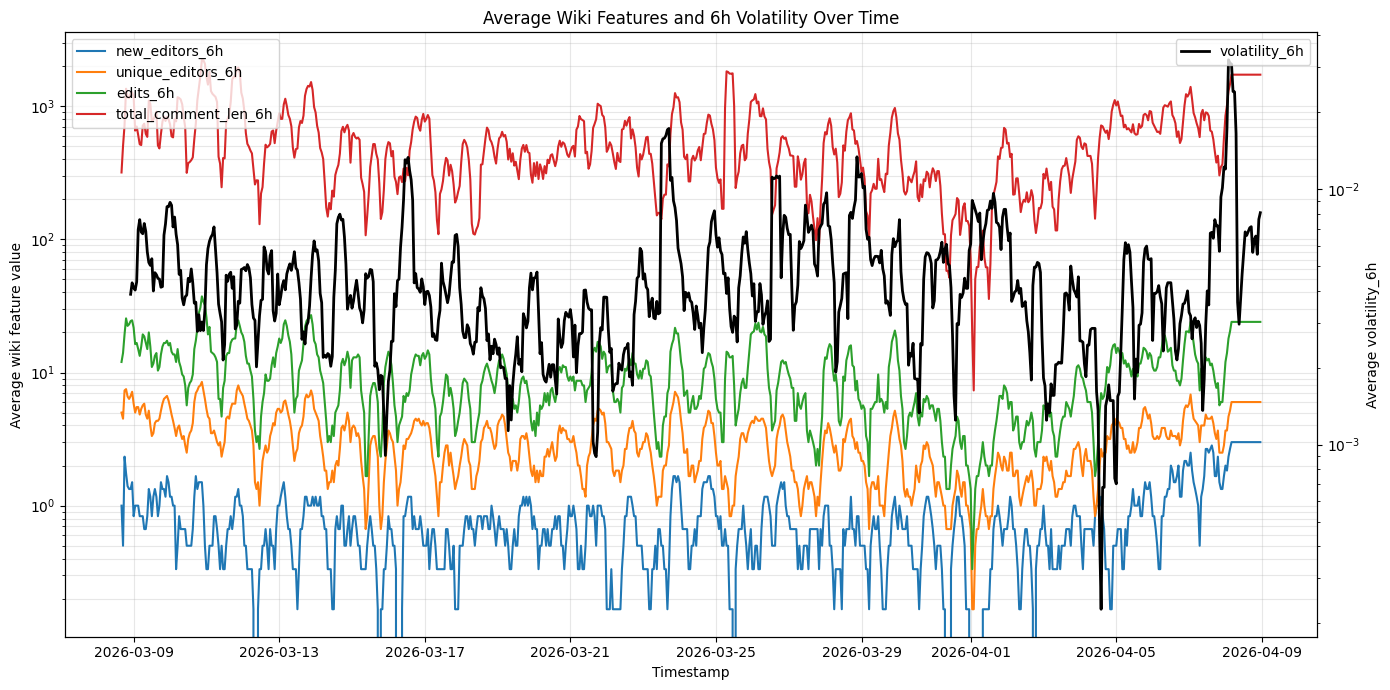

In [11]:
import matplotlib.pyplot as plt
df = df.loc[:, ~df.columns.duplicated()].copy()
features_to_plot = [
    "new_editors_6h",
    "unique_editors_6h",
    "edits_6h",
    "total_comment_len_6h",
]
agg = (
    df.sort_values("timestamp")
      .groupby("timestamp")[features_to_plot + ["volatility_6h"]]
      .mean()
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

for feature in features_to_plot:
    ax1.plot(agg["timestamp"], agg[feature], label=feature, linewidth=1.5)

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Average wiki feature value")
ax1.set_yscale("log")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3, which="both")

ax2 = ax1.twinx()
ax2.plot(agg["timestamp"], agg["volatility_6h"], label="volatility_6h", color="black", linewidth=2)
ax2.set_ylabel("Average volatility_6h")
ax2.set_yscale("log")
ax2.legend(loc="upper right")

plt.title("Average Wiki Features and 6h Volatility Over Time")
plt.tight_layout()
plt.show()

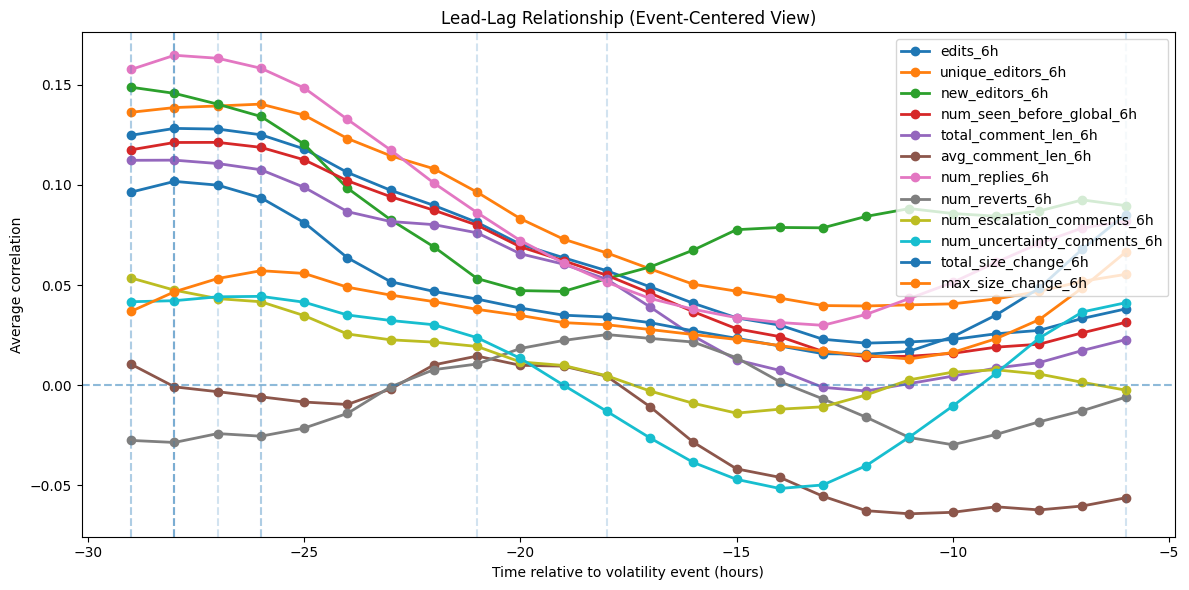

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [col + "_6h" for col in wiki_cols]

max_lag = 24
target_horizon = 6

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["volatility_6h"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)
    avg_corr = corr_df.mean(axis=1)

    # NEGATIVE time axis
    time_to_event = -(np.arange(max_lag) + target_horizon)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

    # mark strongest signal
    best_idx = np.argmax(avg_corr)
    best_time = -(best_idx + target_horizon)
    plt.axvline(best_time, linestyle="--", alpha=0.2)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xlabel("Time relative to volatility event (hours)")
plt.ylabel("Average correlation")
plt.title("Lead-Lag Relationship (Event-Centered View)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# remove duplicate dataframe columns from repeated cell runs
df = df.loc[:, ~df.columns.duplicated()].copy()

### Text Processing with SVD

In [14]:
import re
from html import unescape
def remove_wiki_usernames(text):
    return re.sub(r"\b[a-zA-Z]*editor\d+\b", " ", text, flags=re.IGNORECASE)

def clean_html(text):
    if not isinstance(text, str):
        return ""

    # Unescape HTML entities (&amp;, &lt;, etc.)
    text = unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove leftover markup artifacts
    text = re.sub(r"\{\{.*?\}\}", " ", text)   # templates
    text = re.sub(r"\[\[|\]\]", " ", text)     # wiki links
    text = re.sub(r"\|", " ", text)

    # Keep only words (remove weird punctuation)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text.lower()

def extract_added_text(html):
    if not isinstance(html, str):
        return ""

    added = re.findall(r"<ins[^>]*>(.*?)</ins>", html, flags=re.DOTALL)
    added_text = " ".join(added)

    return clean_html(added_text)
    
    

In [15]:
WIKI_STOP_WORDS = {
    "yes", "no", "ok", "okay", "done", "fixed", "added", "removed", "update", "updated", "change", "changed", "edit", "edited", "user", "wikipedia", "war",
    "revert", "rv", "undo", "undid", "restored", "consensus", "discussion", "talk", "page", "per", "per wp", "per policy", "see talk", "source", "sources", "citation", "cited", "reliable", "unreliable", "rs", "wp", "npov", "neutral", "bias", "biased", "undue", "weight",
    "stub", "cleanup", "expand", "expanded", "tag", "tagged", "template", "infobox", "citation needed", "cn", "ref", "refs", "commment",
    "html", "nbsp", "br", "div", "span", "table", "row", "col", "class", "style",
    "utc", "january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december", "title", "day",
    "fa", "hrana", "abo", "thday", "low", "importance", "high", "mid", "article", "section", "entry", "add",
    "please", "thanks", "thank", "help", "agree", "disagree", "support", "oppose", "question", "answer", "answered",
    "using", "used", "work", "working", "want", "like", "make", "made", "time", "times", "new", "old",
    "edit", "edited", "revert", "rv", "undo", "page", "talk", "wp", "rs", "ref", "template", "yes", "no", "ok", "thanks", "please", "fa", "abo", "utc", "make", "use", "work", "want",
    "comment", "contribution", "contributions", "special", "signature", "signatures", "preceding", "unsigned", "contrib", "contribs", "permalink", "destination", "requested", "rfcid", "ans", "blp", "collapsed", "relisting",
}
import spacy
def looks_like_username(token):
    return (
        len(token) > 10 or
        any(char.isdigit() for char in token)
    )
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
def spacy_tokenizer(text):
    doc = nlp(text)
    custom_stop = WIKI_STOP_WORDS
    tokens = []
    for token in doc:
        lemma = token.lemma_.lower()
        if (
            token.is_stop or
            token.is_punct or
            not token.is_alpha or
            len(lemma) < 3 or
            len(lemma) > 15 or
            any(ch.isdigit() for ch in lemma) or
            lemma in custom_stop or 
            looks_like_username(lemma)
        ):
            continue
        tokens.append(lemma)
    return tokens


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

# remove old tfidf columns
df = df.drop(
    columns=[c for c in df.columns if c.startswith("tfidf_svd_")],
    errors="ignore"
)

# prepare text
rev_text = all_revisions.copy()
rev_text["timestamp"] = pd.to_datetime(rev_text["timestamp"], utc=True)
rev_text["hour"] = rev_text["timestamp"].dt.floor("h")

rev_text["diff_html"] = rev_text.get("diff_html", "").fillna("").astype(str)
rev_text["diff_clean"] = rev_text["diff_html"].apply(extract_added_text)
rev_text["diff_clean"] = rev_text["diff_clean"].apply(remove_wiki_usernames)

# optional: only spike-hour revisions
df["edit_spike"] = (
    df.groupby("market_slug")["edits"]
    .transform(lambda s: s > s.quantile(0.9))
)

spike_hours = df.loc[df["edit_spike"], "timestamp"].unique()
rev_text_model = rev_text[rev_text["hour"].isin(spike_hours)].copy()

print("Total revisions:", len(rev_text))
print("Spike revisions:", len(rev_text_model))

# ONE vectorizer
vectorizer = TfidfVectorizer(
    max_features=300,
    tokenizer=spacy_tokenizer,
    token_pattern=None,
    lowercase=False,
    min_df=5,
    max_df=0.8,
    stop_words=None,
    ngram_range=(1, 1),
)

X_tfidf = vectorizer.fit_transform(rev_text_model["diff_clean"])
terms = vectorizer.get_feature_names_out()

# SVD
n_components = min(10, X_tfidf.shape[1] - 1)

svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

text_cols = [f"tfidf_svd_{i}" for i in range(X_svd.shape[1])]

svd_df = pd.DataFrame(
    X_svd,
    columns=text_cols,
    index=rev_text_model.index
)

rev_text_model = pd.concat([rev_text_model, svd_df], axis=1)

# aggregate hourly
tfidf_hourly = (
    rev_text_model.groupby("hour")[text_cols]
    .mean()
    .reset_index()
    .rename(columns={"hour": "timestamp"})
)

# merge
df = df.loc[:, ~df.columns.duplicated()].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = pd.merge_asof(
    df.sort_values("timestamp"),
    tfidf_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df[text_cols] = df[text_cols].fillna(0)
df = df.sort_values(["market_slug", "timestamp"]).copy()

print("Added:", text_cols)
print("Explained variance:", svd.explained_variance_ratio_)

Total revisions: 26660
Spike revisions: 1578
Added: ['tfidf_svd_0', 'tfidf_svd_1', 'tfidf_svd_2', 'tfidf_svd_3', 'tfidf_svd_4', 'tfidf_svd_5', 'tfidf_svd_6', 'tfidf_svd_7', 'tfidf_svd_8', 'tfidf_svd_9']
Explained variance: [0.28771937 0.12614445 0.08658178 0.07214093 0.06948932 0.06038378
 0.0551168  0.05355801 0.04951077 0.0407058 ]


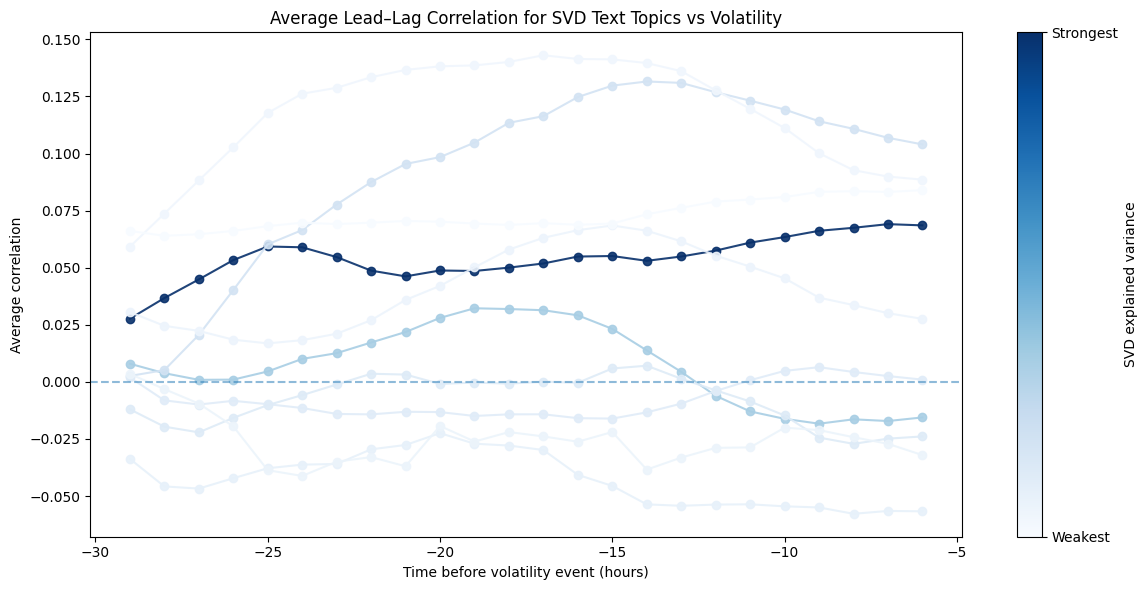

In [17]:
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

max_lag = 24
target_horizon = 6

explained = np.array(svd.explained_variance_ratio_)
norm = Normalize(vmin=explained.min(), vmax=explained.max())
cmap = cm.Blues

time_to_event = -(np.arange(max_lag) + target_horizon)

plt.figure(figsize=(12, 6))

for i, col in enumerate(text_cols):
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()
        target = g["volatility_6h"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[col].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df_temp = pd.DataFrame(market_corrs)
    avg_corr = corr_df_temp.mean(axis=1)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=1.5,
        color=cmap(norm(explained[i])),
        alpha=0.9
    )

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Average Lead–Lag Correlation for SVD Text Topics vs Volatility")
plt.xlabel("Time before volatility event (hours)")
plt.ylabel("Average correlation")

# Colorbar instead of legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("SVD explained variance")
cbar.set_ticks([explained.min(), explained.max()])
cbar.set_ticklabels(["Weakest", "Strongest"])

plt.tight_layout()
plt.show()

In [18]:
def get_topic_keywords_both_sides(svd, terms, topic_idx, top_n=15):
    weights = svd.components_[topic_idx]

    pos_idx = np.argsort(weights)[::-1][:top_n]
    neg_idx = np.argsort(weights)[:top_n]

    pos = pd.DataFrame({
        "term": terms[pos_idx],
        "weight": weights[pos_idx],
        "side": "positive"
    })

    neg = pd.DataFrame({
        "term": terms[neg_idx],
        "weight": weights[neg_idx],
        "side": "negative"
    })

    return pos, neg
terms = vectorizer.get_feature_names_out()
topic_idx = 0
pos, neg = get_topic_keywords_both_sides(svd, terms, topic_idx)

print("Positive side:")
print(pos.to_string(index=False))

print("\nNegative side:")
print(neg.to_string(index=False))

Positive side:
    term   weight     side
    iran 0.996289 positive
   right 0.052778 positive
 current 0.038904 positive
 involve 0.035052 positive
    list 0.025488 positive
 iranian 0.024702 positive
official 0.024153 positive
   claim 0.004300 positive
 mention 0.002480 positive
  attack 0.002116 positive
 country 0.001985 positive
conflict 0.001688 positive
   state 0.000917 positive
 cameron 0.000098 positive
 opinion 0.000096 positive

Negative side:
    term   weight     side
 opinion 0.000096 negative
 cameron 0.000098 negative
   state 0.000917 negative
conflict 0.001688 negative
 country 0.001985 negative
  attack 0.002116 negative
 mention 0.002480 negative
   claim 0.004300 negative
official 0.024153 negative
 iranian 0.024702 negative
    list 0.025488 negative
 involve 0.035052 negative
 current 0.038904 negative
   right 0.052778 negative
    iran 0.996289 negative


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()
df = df.sort_values(["market_slug", "timestamp"]).copy()

kernel = np.array([0.0]*3 + [0.1, 0.15, 0.2, 0.2, 0.15, 0.1, 0.1])
# covers lags ~4–10 hours
kernel = kernel / kernel.sum()
df = df.copy()

signal_cols = []

for col in text_cols + ["edits_6h", "new_editors_6h", "total_comment_len_6h"]:
    
    parts = []
    
    for lag, w in enumerate(kernel, start=1):
        parts.append(
            w * df.groupby("market_slug")[col].shift(lag)
        )
    
    df[f"{col}_signal"] = sum(parts)
    signal_cols.append(f"{col}_signal")

feature_cols = signal_cols
for col in text_cols:
    df[f"{col}_x_new_editors"] = (
        df[f"{col}_signal"] * df["new_editors_6h_signal"]
    )
    feature_cols.append(f"{col}_x_new_editors")
df["text_intensity"] = df[[f"{col}_signal" for col in text_cols]].abs().sum(axis=1)
feature_cols.append("text_intensity")

# -----------------------------
# Clean model frame
# -----------------------------
model_df = pd.concat(
    [df[["market_slug", "timestamp"]], df[feature_cols], df["target"]],
    axis=1
).dropna()

model_df = model_df.sort_values("timestamp")

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

threshold = train_df["target"].quantile(0.9)

train_df["big_move"] = (train_df["target"] > threshold).astype(int)
test_df["big_move"] = (test_df["target"] > threshold).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())

print("\nTest class counts:")
print(test_df["big_move"].value_counts())

if train_df["big_move"].nunique() < 2:
    raise ValueError("Training set has only one class. Lower threshold or get more data.")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["big_move"]
y_test = test_df["big_move"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, C=0.05, penalty="l1", solver="liblinear")
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print("\nAUC:", auc)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

coef_df_pos = coef_df.sort_values("coef", ascending=False)
coef_df_neg = coef_df.sort_values("coef", ascending=True)

print("\nTop positive:")
print(coef_df_pos.head(10))

print("\nTop negative:")
print(coef_df_neg.head(10))

Train class counts:
big_move
0    4207
1     467
Name: count, dtype: int64

Test class counts:
big_move
0    1737
1     267
Name: count, dtype: int64

AUC: 0.5744762052615577

Top positive:
                      feature      coef
4          tfidf_svd_4_signal  0.194595
15  tfidf_svd_2_x_new_editors  0.146073
19  tfidf_svd_6_x_new_editors  0.024318
8          tfidf_svd_8_signal  0.015881
23             text_intensity  0.000000
2          tfidf_svd_2_signal  0.000000
3          tfidf_svd_3_signal  0.000000
5          tfidf_svd_5_signal  0.000000
6          tfidf_svd_6_signal  0.000000
7          tfidf_svd_7_signal  0.000000

Top negative:
                        feature      coef
10              edits_6h_signal -0.083712
12  total_comment_len_6h_signal -0.047888
2            tfidf_svd_2_signal  0.000000
3            tfidf_svd_3_signal  0.000000
5            tfidf_svd_5_signal  0.000000
6            tfidf_svd_6_signal  0.000000
7            tfidf_svd_7_signal  0.000000
9            tfidf_

In [20]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5456327259319633


In [21]:
shuffle_aucs = []

for seed in tqdm(range(50)):
    y_perm = y_train.sample(frac=1, random_state=seed)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train_scaled, y_perm)
    pred = m.predict_proba(X_test_scaled)[:, 1]
    shuffle_aucs.append(roc_auc_score(y_test, pred))

print("Real AUC:", auc)
print("Shuffle mean:", np.mean(shuffle_aucs))
print("Shuffle max:", np.max(shuffle_aucs))

100%|██████████| 50/50 [00:00<00:00, 124.27it/s]

Real AUC: 0.5744762052615577
Shuffle mean: 0.5125893151695097
Shuffle max: 0.5935844443150724


#### SVD vizs

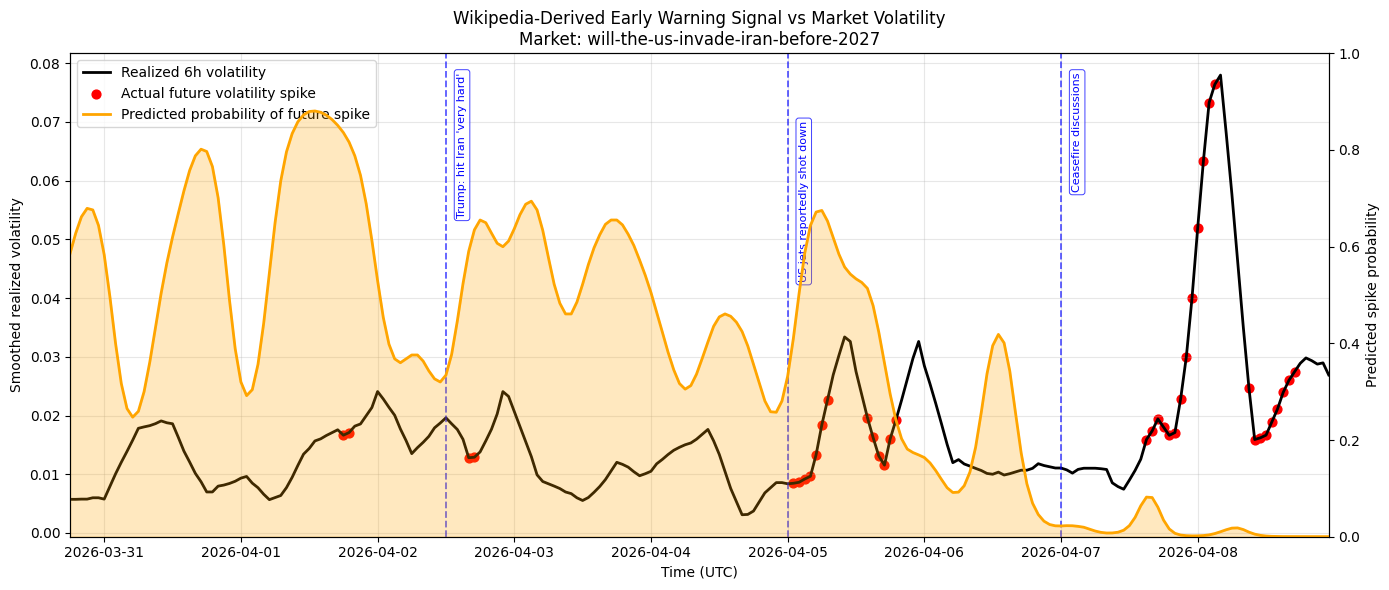


Feature importance:
                     feature      coef
1         tfidf_svd_3_signal  0.470540
0  tfidf_svd_2_x_new_editors  0.027441
2      new_editors_6h_signal -0.921326


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# -----------------------------
# CONFIG
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"

signal_cols = [
    "tfidf_svd_2_x_new_editors",
    "tfidf_svd_3_signal",
    "new_editors_6h_signal",
]

vol_col = "volatility_6h"

lag = 6
smooth_window = 6
vol_quantile = 0.9

# -----------------------------
# SELECT MARKET
# -----------------------------
g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

# -----------------------------
# BUILD TARGET
# -----------------------------
g["vol_smooth"] = (
    g[vol_col]
    .rolling(smooth_window)
    .mean()
)

future_vol = g["vol_smooth"].shift(-lag)

threshold = future_vol.quantile(vol_quantile)

g["future_spike"] = (
    future_vol > threshold
).astype(int)

# -----------------------------
# BUILD FEATURES
# -----------------------------
for col in signal_cols:
    g[col] = (
        g[col]
        .rolling(smooth_window)
        .mean()
    )

model_df = g[
    ["timestamp", "vol_smooth", "future_spike"] + signal_cols
].dropna()

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split]
test_df = model_df.iloc[split:]

X_train = train_df[signal_cols]
X_test = test_df[signal_cols]

y_train = train_df["future_spike"]
y_test = test_df["future_spike"]

# -----------------------------
# SCALE
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# FIT MODEL
# -----------------------------
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# PREDICT PROBABILITIES
# -----------------------------
model_df.loc[test_df.index, "pred_prob"] = (
    model.predict_proba(X_test_scaled)[:,1]
)

# -----------------------------
# PLOT
# -----------------------------
plot_df = model_df.loc[test_df.index].copy()

fig, ax1 = plt.subplots(figsize=(14,6))

# realized volatility
ax1.plot(
    plot_df["timestamp"],
    plot_df["vol_smooth"],
    color="black",
    linewidth=2,
    label="Realized 6h volatility"
)

ax1.set_ylabel("Smoothed realized volatility")

# probability axis
ax2 = ax1.twinx()

ax2.plot(
    plot_df["timestamp"],
    plot_df["pred_prob"],
    color="orange",
    linewidth=2,
    label="Predicted probability of future spike"
)

ax2.fill_between(
    plot_df["timestamp"],
    0,
    plot_df["pred_prob"],
    color="orange",
    alpha=0.25
)

ax2.set_ylim(0, 1)
ax2.set_ylabel("Predicted spike probability")

# -----------------------------
# HIGHLIGHT ACTUAL SPIKES
# -----------------------------
actual_spikes = plot_df["future_spike"] == 1

ax1.scatter(
    plot_df.loc[actual_spikes, "timestamp"],
    plot_df.loc[actual_spikes, "vol_smooth"],
    color="red",
    s=40,
    label="Actual future volatility spike"
)
# -----------------------------
# AP / news events
# -----------------------------
news_events = [
    {
        "time": "2026-03-18 23:00:00+00:00",
        "label": "Iran missile launch"
    },
    {
        "time": "2026-03-19 06:00:00+00:00",
        "label": "Israeli strikes on Tehran"
    },
    {
        "time": "2026-04-02 12:00:00+00:00",
        "label": "Trump: hit Iran 'very hard'"
    },
    {
        "time": "2026-04-05 00:00:00+00:00",
        "label": "US jets reportedly shot down"
    },
    {
        "time": "2026-04-07 00:00:00+00:00",
        "label": "Ceasefire discussions"
    },
]
# -----------------------------
# Add news event markers
# -----------------------------
for i, event in enumerate(news_events):
    t = pd.to_datetime(event["time"], utc=True)

    ax1.axvline(
        x=t,
        color="blue",
        linestyle="--",
        linewidth=1.3,
        alpha=0.65
    )

    # alternate label heights to reduce overlap
    y_frac = 0.96 if i % 2 == 0 else 0.86

    ax1.annotate(
        event["label"],
        xy=(t, y_frac),
        xycoords=("data", "axes fraction"),

        # move text rightward away from line
        xytext=(8, 0),
        textcoords="offset points",

        rotation=90,
        va="top",
        ha="left",

        fontsize=8,
        color="blue",

        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="blue",
            alpha=0.75,
            linewidth=0.7
        ),

        clip_on=True,
        zorder=10
    )
# -----------------------------
# TITLES
# -----------------------------
plt.title(
    f"Wikipedia-Derived Early Warning Signal vs Market Volatility\n"
    f"Market: {slug}"
)

ax1.set_xlabel("Time (UTC)")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

ax1.grid(alpha=0.3)
plt.xlim(plot_df["timestamp"].min(), plot_df["timestamp"].max())
plt.tight_layout()
plt.show()

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
coef_df = pd.DataFrame({
    "feature": signal_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

print("\nFeature importance:")
print(coef_df)

### Hawkes Process

In [23]:
import numpy as np

# -----------------------------
# 1. Select market + clean
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"

g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

t0 = g["timestamp"].min()
t_max = g["timestamp"].max()

# -----------------------------
# 2. Define volatility spikes
# -----------------------------
threshold = g["volatility_6h"].quantile(0.8)
g["vol_spike"] = (g["volatility_6h"] > threshold).astype(int)
g["edit_burst"] = (
    g["edits"] > g["edits"].quantile(0.9)
).astype(int)

# -----------------------------
# 3. Market event times (spikes)
# -----------------------------
market_event_times = (
    (g.loc[g["vol_spike"] == 1, "timestamp"] - t0)
    .dt.total_seconds()
    / 3600
).to_numpy()

# -----------------------------
# 4. Wiki event times (raw revisions)
# -----------------------------
# wiki_event_times = (
#     (all_revisions["timestamp"] - t0)
#     .dt.total_seconds()
#     / 3600
# )

burst_times = (
    (g.loc[g["edit_burst"] == 1, "timestamp"] - t0)
    .dt.total_seconds() / 3600
)

# restrict to same time window as market
T = (t_max - t0).total_seconds() / 3600

wiki_event_times = burst_times[
    (burst_times >= 0) &
    (burst_times <= T)
].to_numpy()

# -----------------------------
# 5. Event-study function
# -----------------------------
def count_future_spikes(source_times, target_times, horizon):
    counts = []
    for t in source_times:
        n = ((target_times > t) & (target_times <= t + horizon)).sum()
        counts.append(n)
    return np.array(counts)

# -----------------------------
# 6. Run experiment
# -----------------------------
print("Avg # of volatility spikes after a wiki edit:")

for h in [1, 3, 6, 12, 24]:
    counts = count_future_spikes(wiki_event_times, market_event_times, h)
    print(f"{h}h: {counts.mean():.4f}")

Avg # of volatility spikes after a wiki edit:
1h: 0.0638
3h: 0.2553
6h: 0.5319
12h: 0.8511
24h: 2.3191


In [24]:
# -----------------------------
# 7. Compare to random baseline
# -----------------------------
rng = np.random.default_rng(42)

random_times = rng.uniform(0, T, size=len(wiki_event_times))

print("\nComparison vs random:")

for h in [1, 3, 6, 12, 24]:
    real = count_future_spikes(wiki_event_times, market_event_times, h).mean()
    rand = count_future_spikes(random_times, market_event_times, h).mean()
    
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")

print("-------Opposite Direction-------")
for h in [1,3,6,12,24]:
    real = count_future_spikes(market_event_times, wiki_event_times, h).mean()
    rand = count_future_spikes(random_times, wiki_event_times, h).mean()
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")


Comparison vs random:
1h | real: 0.0638 | random: 0.2553
3h | real: 0.2553 | random: 0.6809
6h | real: 0.5319 | random: 1.4255
12h | real: 0.8511 | random: 2.9574
24h | real: 2.3191 | random: 6.4468
-------Opposite Direction-------
1h | real: 0.0201 | random: 0.0213
3h | real: 0.0805 | random: 0.1702
6h | real: 0.2148 | random: 0.4681
12h | real: 0.5369 | random: 0.7234
24h | real: 0.9933 | random: 1.0638


In [25]:
diffs = count_future_spikes(wiki_event_times, market_event_times, 6) - \
        count_future_spikes(random_times, market_event_times, 6)

print("Mean diff:", diffs.mean())
print("Std diff:", diffs.std())

boot = []
rng = np.random.default_rng(0)

for _ in range(1000):
    sample = rng.choice(diffs, size=len(diffs), replace=True)
    boot.append(sample.mean())

print("95% CI:", np.percentile(boot, [2.5, 97.5]))

Mean diff: -0.8936170212765957
Std diff: 2.4077361359035603
95% CI: [-1.53191489 -0.21223404]
